# Feature Selection

## Objective

This notebook identifies the most informative industrial sensors for anomaly detection in the SWaT dataset.

The following techniques are used:

- Random Sampling
- Variance Threshold
- Correlation Analysis
- Random Forest Feature Importance

In [1]:
import numpy as np
import pandas as pd


from pathlib import Path

from sklearn.feature_selection import VarianceThreshold

from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

import seaborn as sns

plt.style.use("ggplot")

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "swat_features.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Target
0,0.538116,-0.567030,0.335953,0.60675,-0.046608,2.994988,-0.299856,-0.248463,0.603097,0.321655,...,0.165048,0.0,0.143557,1.727161,0.133610,-0.098181,0.0,-0.091453,0.0,0
1,0.554769,-0.566712,0.335953,0.60675,-0.046608,2.994988,-0.299856,-0.248463,0.603097,0.321655,...,0.165048,0.0,0.143557,1.727161,0.136315,-0.098181,0.0,-0.091453,0.0,0
2,0.591961,-0.567030,0.335953,0.60675,-0.046608,2.994988,-0.316133,-0.248463,0.600262,0.321655,...,0.165048,0.0,0.143974,1.727161,0.136315,-0.098181,0.0,-0.091453,0.0,0
3,0.631096,-0.566079,0.335953,0.60675,-0.046608,2.994988,-0.316133,-0.248463,0.600262,0.321655,...,0.165048,0.0,0.143974,1.727161,0.134150,-0.098181,0.0,-0.091453,0.0,0
4,0.661349,-0.561962,0.335953,0.60675,-0.046608,2.994988,-0.316133,-0.248463,0.600971,0.321655,...,0.165048,0.0,0.143974,1.727161,0.130365,-0.098181,0.0,-0.091453,0.0,0


In [3]:
print("="*50)
print("Dataset Information")
print("="*50)

print(df.shape)

print()

print(df.info())

print()

print(df["Target"].value_counts())

Dataset Information
(548040, 52)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548040 entries, 0 to 548039
Data columns (total 52 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   FIT101   548040 non-null  float64
 1   LIT101   548040 non-null  float64
 2   MV101    548040 non-null  float64
 3   P101     548040 non-null  float64
 4   P102     548040 non-null  float64
 5   AIT201   548040 non-null  float64
 6   AIT202   548040 non-null  float64
 7   AIT203   548040 non-null  float64
 8   FIT201   548040 non-null  float64
 9   MV201    548040 non-null  float64
 10  P201     548040 non-null  float64
 11  P202     548040 non-null  float64
 12  P203     548040 non-null  float64
 13  P204     548040 non-null  float64
 14  P205     548040 non-null  float64
 15  P206     548040 non-null  float64
 16  DPIT301  548040 non-null  float64
 17  FIT301   548040 non-null  float64
 18  LIT301   548040 non-null  float64
 19  MV301    548040 non-null  float

### Random Sampling

The original dataset contains more than 1.4 million observations.

To reduce computational cost during feature selection,
a representative random sample is used.

In [4]:
sample_df = df.sample(
    n=100000,
    random_state=42
)

sample_df.shape

(100000, 52)

In [5]:
X = sample_df.drop(columns="Target")

y = sample_df["Target"]

In [6]:
selector = VarianceThreshold(
    threshold=0.001
)

selector.fit(X)

selected_features = X.columns[
    selector.get_support()
]

removed_features = X.columns[
    ~selector.get_support()
]

In [7]:
print("Selected Features :", len(selected_features))

print("Removed Features :", len(removed_features))

Selected Features : 43
Removed Features : 8


In [8]:
removed_features.tolist()

['P202', 'P204', 'P206', 'P401', 'P404', 'P502', 'P601', 'P603']

In [9]:
corr = X[selected_features].corr().abs()

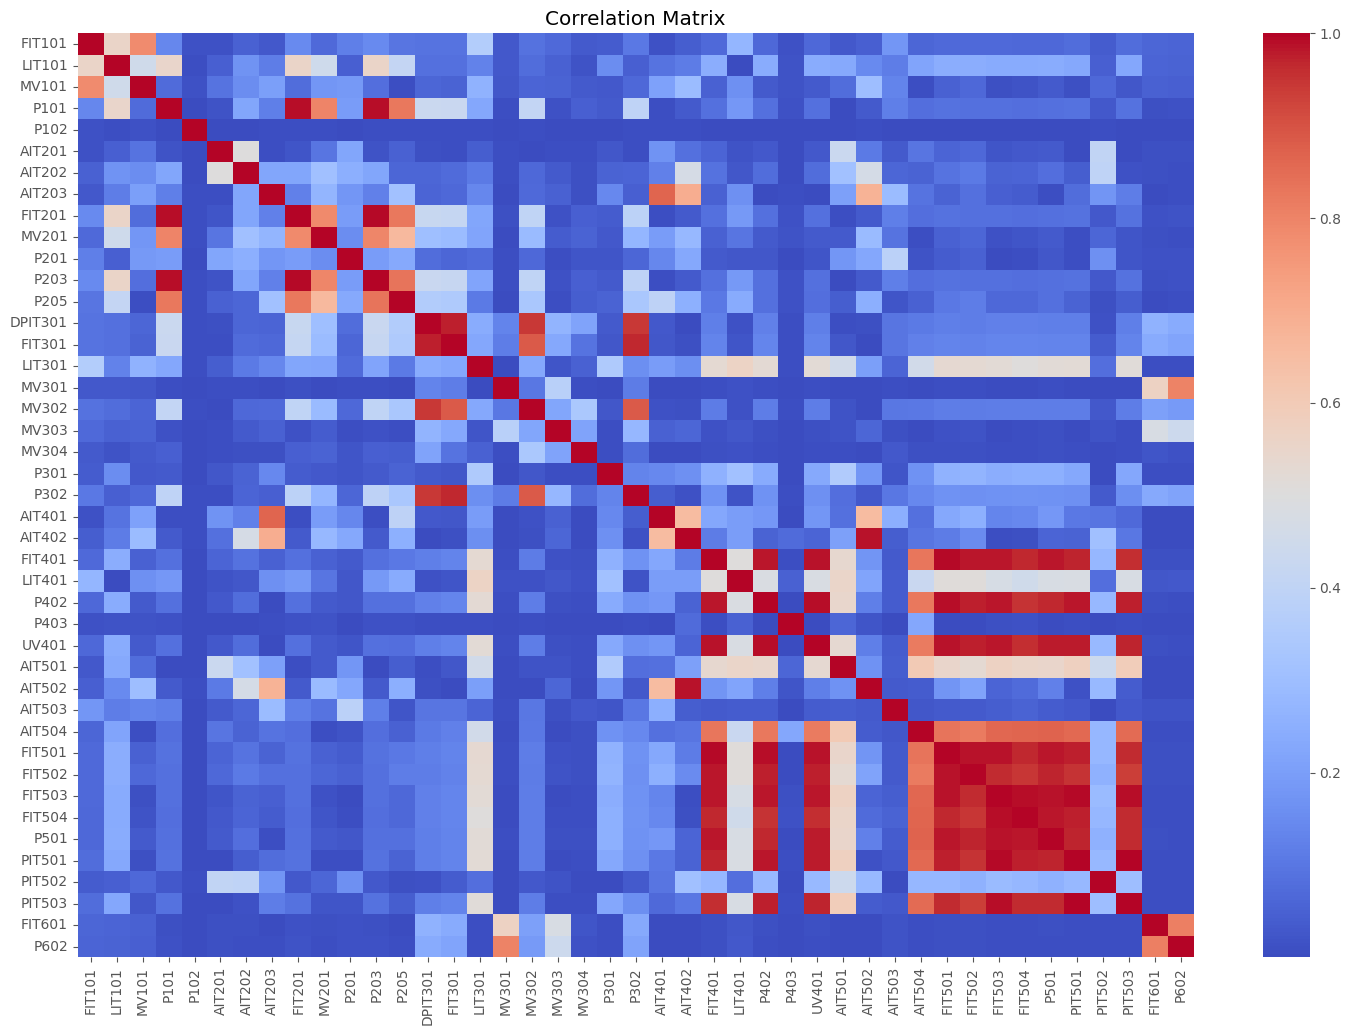

In [10]:
plt.figure(figsize=(18,12))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [11]:
upper = corr.where(
    np.triu(
        np.ones(corr.shape),
        k=1
    ).astype(bool)
)

In [12]:
high_corr = upper.stack()

high_corr = high_corr.sort_values(
    ascending=False
)

high_corr.head(20)

PIT501  PIT503    0.998389
FIT201  P203      0.995850
FIT503  PIT501    0.994552
FIT401  FIT501    0.993874
P101    P203      0.991417
P402    FIT501    0.991280
P101    FIT201    0.991200
P402    UV401     0.989923
FIT503  FIT504    0.989276
        PIT503    0.988916
FIT501  FIT502    0.988198
AIT402  AIT502    0.987097
FIT401  UV401     0.986721
UV401   FIT501    0.986607
FIT503  P501      0.985193
FIT501  FIT503    0.984810
FIT401  P402      0.983146
P402    PIT501    0.982889
        FIT503    0.982655
FIT401  FIT502    0.982553
dtype: float64

In [13]:
to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95)
]

In [14]:
print(len(to_drop))

to_drop

14


['FIT201',
 'P203',
 'FIT301',
 'P302',
 'P402',
 'UV401',
 'AIT502',
 'FIT501',
 'FIT502',
 'FIT503',
 'FIT504',
 'P501',
 'PIT501',
 'PIT503']

In [15]:
X_reduced = X.drop(
    columns=to_drop
)

In [16]:
print(X_reduced.shape)

(100000, 37)


In [17]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [18]:
rf.fit(
    X_reduced,
    y
)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [19]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_reduced.columns
)

In [20]:
importance = importance.sort_values(
    ascending=False
)

In [21]:
importance.head(20)

FIT101    0.0
MV304     0.0
AIT401    0.0
AIT402    0.0
FIT401    0.0
LIT401    0.0
P401      0.0
P403      0.0
P404      0.0
AIT501    0.0
AIT503    0.0
AIT504    0.0
P502      0.0
PIT502    0.0
FIT601    0.0
P601      0.0
P602      0.0
P301      0.0
MV303     0.0
LIT101    0.0
dtype: float64

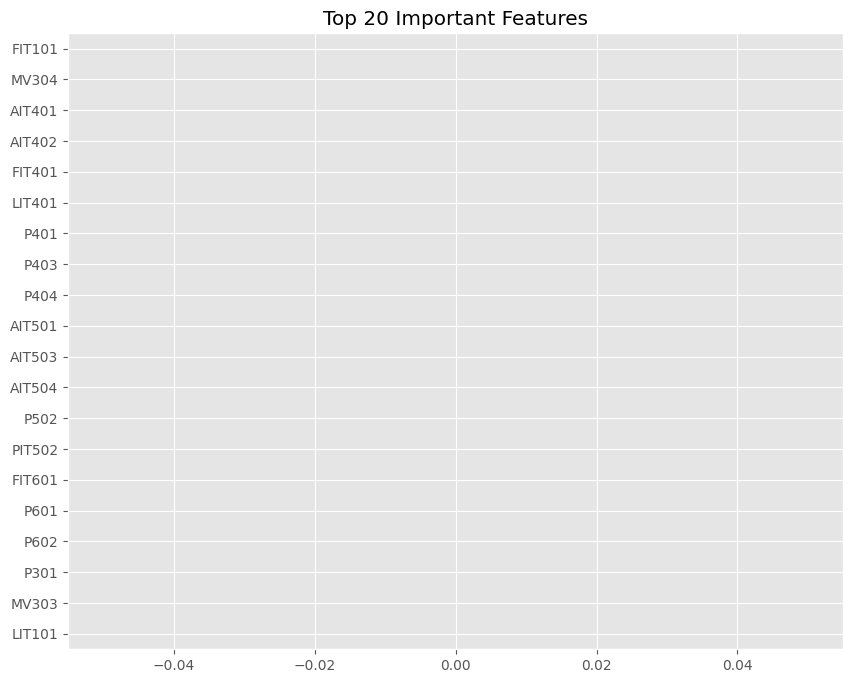

In [22]:
plt.figure(figsize=(10,8))

importance.head(20).plot.barh()

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

In [23]:
top_features = importance.head(20).index.tolist()

top_features

['FIT101',
 'MV304',
 'AIT401',
 'AIT402',
 'FIT401',
 'LIT401',
 'P401',
 'P403',
 'P404',
 'AIT501',
 'AIT503',
 'AIT504',
 'P502',
 'PIT502',
 'FIT601',
 'P601',
 'P602',
 'P301',
 'MV303',
 'LIT101']

In [24]:
final_df = df[top_features].copy()

final_df["Target"] = df["Target"]

In [25]:
final_df.head()

,FIT101,MV304,AIT401,AIT402,FIT401,LIT401,P401,P403,P404,AIT501,...,AIT504,P502,PIT502,FIT601,P601,P602,P301,MV303,LIT101,Target
0,0.538116,-0.19764,0.355936,-0.446594,0.169928,0.575680,0.0,-0.006451,0.0,0.461353,...,-0.115805,0.0,1.727161,-0.098181,0.0,-0.091453,-0.051067,-0.071481,-0.567030,0
1,0.554769,-0.19764,0.355936,-0.446594,0.178809,0.575386,0.0,-0.006451,0.0,0.461353,...,-0.115805,0.0,1.727161,-0.098181,0.0,-0.091453,-0.051067,-0.071481,-0.566712,0
2,0.591961,-0.19764,0.355936,-0.446594,0.178809,0.574212,0.0,-0.006451,0.0,0.461353,...,-0.115805,0.0,1.727161,-0.098181,0.0,-0.091453,-0.051067,-0.071481,-0.567030,0
3,0.631096,-0.19764,0.355936,-0.446594,0.174133,0.573625,0.0,-0.006451,0.0,0.461353,...,-0.115805,0.0,1.727161,-0.098181,0.0,-0.091453,-0.051067,-0.071481,-0.566079,0
4,0.661349,-0.19764,0.355936,-0.446594,0.174133,0.576854,0.0,-0.006451,0.0,0.461353,...,-0.115805,0.0,1.727161,-0.098181,0.0,-0.091453,-0.051067,-0.071481,-0.561962,0


In [ ]:
SAVE_PATH = PROJECT_ROOT/"data"/"processed"/"selected_features.csv"

final_df.to_csv(
    SAVE_PATH,
    index=False
)

print("Dataset Saved Successfully")

# Summary

A representative sample of the SWaT dataset was used to reduce computational cost.

Low variance features were removed.

Highly correlated sensors were eliminated.

Random Forest Feature Importance identified the most informative industrial sensors.

The resulting dataset is ready for model development.